# Cod Drumming Detection — Long-File Pipeline

`main.ipynb` classifies **pre-cut clips**. This notebook takes a long (5–45 min) **unannotated** recording and have the model
**find and classify the cod sounds itself** — no manual cutting.

It mirrors the `src/inference/detect.py` command-line pipeline. **Steps:**
1. Why long files need a different approach
2. **Detect** candidate events (energy detector)
3. **Embed** each event once at its native detected extent with Perch
4. **Classify** each event
5. **Evaluate** against the Raven selection-table ground truth

All code uses functions from `src/`, `src/inference/detect.py`, and `src/inference/evaluate_detection.py` — nothing new is
defined here.

> **Note (2026-06-10):** an earlier version embedded each event at *multiple* widths (10/50/200 ms)
> and kept the most-confident scale. The data analysis in `src/data/analysis/` showed the 10 ms
> crop collapses *every* class into `click`, so that path was reverted. This notebook now uses the
> **single-pass** supported pipeline. See `CLAUDE.md` → "Data analysis" / "Single-pass baseline".

In [1]:
# Make sure the project root is the working directory so all paths work
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working directory:', os.getcwd())

Working directory: /home/coder/Cod-Drumming-Classification


## 1. Why long files need a different pipeline

Perch has a **fixed 5-second input** and **mean-pools** its embedding over the whole window.
The cod sounds are tiny — a click is ~2 ms, a vocal grunt ~45 ms. So if we naively tile a long
file into 5-second windows (see `src/inference/infer.py`), a 2 ms click is averaged against ~5 s of background
and **vanishes** — the model only ever sees 'background'. On real files that approach finds
**zero** cod sounds.

**The fix (this pipeline / `src/inference/detect.py`):**
1. **Detect** the short events first, at their own millisecond timescale.
2. **Embed each event once** at its native detected extent (+ a small pad), so each sound is
   judged at its own measured duration — matching how the annotated training clips were cut.
3. **Classify** each event with the trained head (plain argmax over class probabilities).

> **Why not multi-scale?** We tried cutting each event at 10/50/200 ms and keeping the most
> confident width. `src/data/analysis/` showed a 10 ms crop makes *every* class embed as `click`
> (and the `max` rule then always picks it), which both misclassified vocals and over-called
> clicks. Single-pass native-extent is simpler and more honest.

> **TF/PyTorch isolation:** Perch (TensorFlow) and the classifier (PyTorch) segfault if loaded
> in the same kernel. Detection embedding therefore runs in a **subprocess**
> (`src/model/detect_long.py`); this notebook's kernel only ever uses PyTorch, so it's safe.

## 2. Choose a long recording

We use a long `_all` file (the full recording the annotated clips were cut from). The matching
`selection_<stem>.txt` next to it is the Raven ground-truth table we'll score against in step 5.
Swap `WAV` for any long file that has a `selection_<stem>.txt` table beside it.

In [2]:
from pathlib import Path
import soundfile as sf
from src.inference.evaluate_detection import find_selection_table

WAV = Path('data/unannotated/01-220412_1221_Ch6_all.wav')

info = sf.info(WAV)
print(f'{WAV.name}: {info.duration/60:.1f} min @ {info.samplerate//1000} kHz')
print('selection table:', find_selection_table(WAV))

01-220412_1221_Ch6_all.wav: 21.6 min @ 96 kHz
selection table: data/unannotated/selection_01-220412_1221_Ch6_all.txt


## 3. Stage 1 — Detect events

`detect_events` band-passes the waveform to the cod frequency range, measures energy in 5 ms
frames, thresholds at `median + k·MAD`, and groups the spikes into events (merging pulse trains,
splitting over-long runs). It's pure NumPy/SciPy — **no TensorFlow**, so it runs live here.
Detector settings live in `src/data/config.py`.

In [3]:
import numpy as np
from src.data.preprocess import load_mono_resampled, detect_events
from src.data.config import (PERCH_SAMPLE_RATE, DETECT_THRESHOLD_K,
                             DETECT_MERGE_GAP_MS, DETECT_PAD_MS)

audio = load_mono_resampled(WAV)            # mono, resampled to 32 kHz
events = detect_events(audio)               # list of (start_sample, end_sample)

durs = np.array([(e - s) / PERCH_SAMPLE_RATE for s, e in events])
print(f'threshold k={DETECT_THRESHOLD_K}, merge_gap={DETECT_MERGE_GAP_MS}ms, pad={DETECT_PAD_MS}ms')
print(f'detected {len(events)} events')
print(f'durations (s): median={np.median(durs):.3f}  min={durs.min():.3f}  max={durs.max():.3f}')

threshold k=3.0, merge_gap=40.0ms, pad=2.0ms
detected 2888 events
durations (s): median=0.005  min=0.005  max=0.500


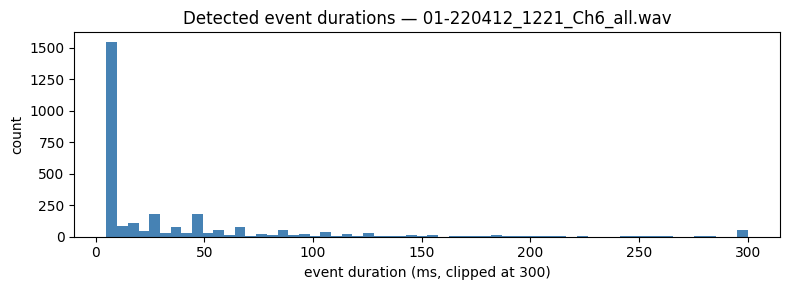

In [4]:
# Most events are very short — the millisecond-scale transients blind tiling would have missed
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.hist(np.clip(durs * 1000, 0, 300), bins=60, color='steelblue')
plt.xlabel('event duration (ms, clipped at 300)'); plt.ylabel('count')
plt.title(f'Detected event durations — {WAV.name}'); plt.tight_layout()
plt.show()

## 4. Stage 2 — Embed each event (Perch, subprocess)

`ensure_detection` runs `src/model/detect_long.py` in a **subprocess**: it detects the events,
cuts each one at its native detected extent (+ a small pad), embeds it with Perch (on the GPU if
available), and caches the result to `data/detection_cache/<stem>.npz`. If the cache already
exists it loads instantly — pass `force=True` to recompute.

The embeddings come back shaped **(n_events, 1536)** — one Perch fingerprint per event.

In [5]:
from src.inference.detect import ensure_detection   # imports PyTorch only; Perch runs in the subprocess

embeddings, starts, ends = ensure_detection(WAV, force=False)
print(f'embeddings: {embeddings.shape}  (events, dim)')

embeddings: (2888, 1536)  (events, dim)


/home/coder/Cod-Drumming-Classification/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 5. Stage 3 — Classify each event

`classify` runs the trained classifier on each event's embedding and takes the most probable
class (argmax over the softmax) with its confidence. Each event is judged at its own native
detected width.

**Which model?** Three heads exist (all 1536→classes on the same Perch embeddings):
- `classifier_logistic.pt` — trained on the biologists' **clean clips** (the baseline, from `main.py`).
- `classifier_domain.pt` — **domain-adapted**: retrained on *detector-cropped* events labelled
  from the selection tables (`python -m src.training.train_domain`). This fixes the train/serve
  mismatch and is the recommended head — we use it below.
- `classifier_domain_bg.pt` — domain-adapted **+ a `background` class** that rejects ~94% of
  detections to cut over-detection (`... train_domain --background`); see §7.

> The file below (`01-220412_1221_Ch6_all`) was **held out** of domain training, so its result is
> an honest test: the domain head scores ~69% correct here vs ~29% for the clean-clip baseline.

In [6]:
from src.model.classifier import load_model
from src.data.config import MODEL_DIR, RESULTS_DIR
from src.training.train import label_names
from src.inference.detect import classify, build_rows, write_csv, plot_timeline
from IPython.display import Image
import pandas as pd

# domain-adapted head (retrained on detector crops). Swap for 'classifier_logistic.pt'
# to see the clean-clip baseline.
model = load_model(MODEL_DIR / 'classifier_domain.pt')
labels = label_names()

class_idx, conf = classify(model, embeddings)
rows = build_rows(class_idx, conf, starts, ends, labels)

out_dir = RESULTS_DIR / 'detection' / WAV.stem
out_dir.mkdir(parents=True, exist_ok=True)
write_csv(rows, out_dir / 'events.csv',
          ['start_s', 'end_s', 'duration_s', 'class', 'confidence'])

# counts per predicted class
ev = pd.DataFrame(rows)
display(ev['class'].value_counts().rename('events'))
ev.head()

Wrote 2888 rows → results/detection/01-220412_1221_Ch6_all/events.csv


class
vocal      1333
silence     965
other       503
click        66
water        21
Name: events, dtype: int64

,start_s,end_s,duration_s,class,confidence
0,0.045,0.11,0.065,other,0.7847
1,0.185,0.19,0.005,other,0.6681
2,0.300,0.32,0.020,vocal,0.6833
3,0.430,0.44,0.010,vocal,0.6755
4,0.545,0.57,0.025,vocal,0.3870


Saved timeline → results/detection/01-220412_1221_Ch6_all/timeline.png


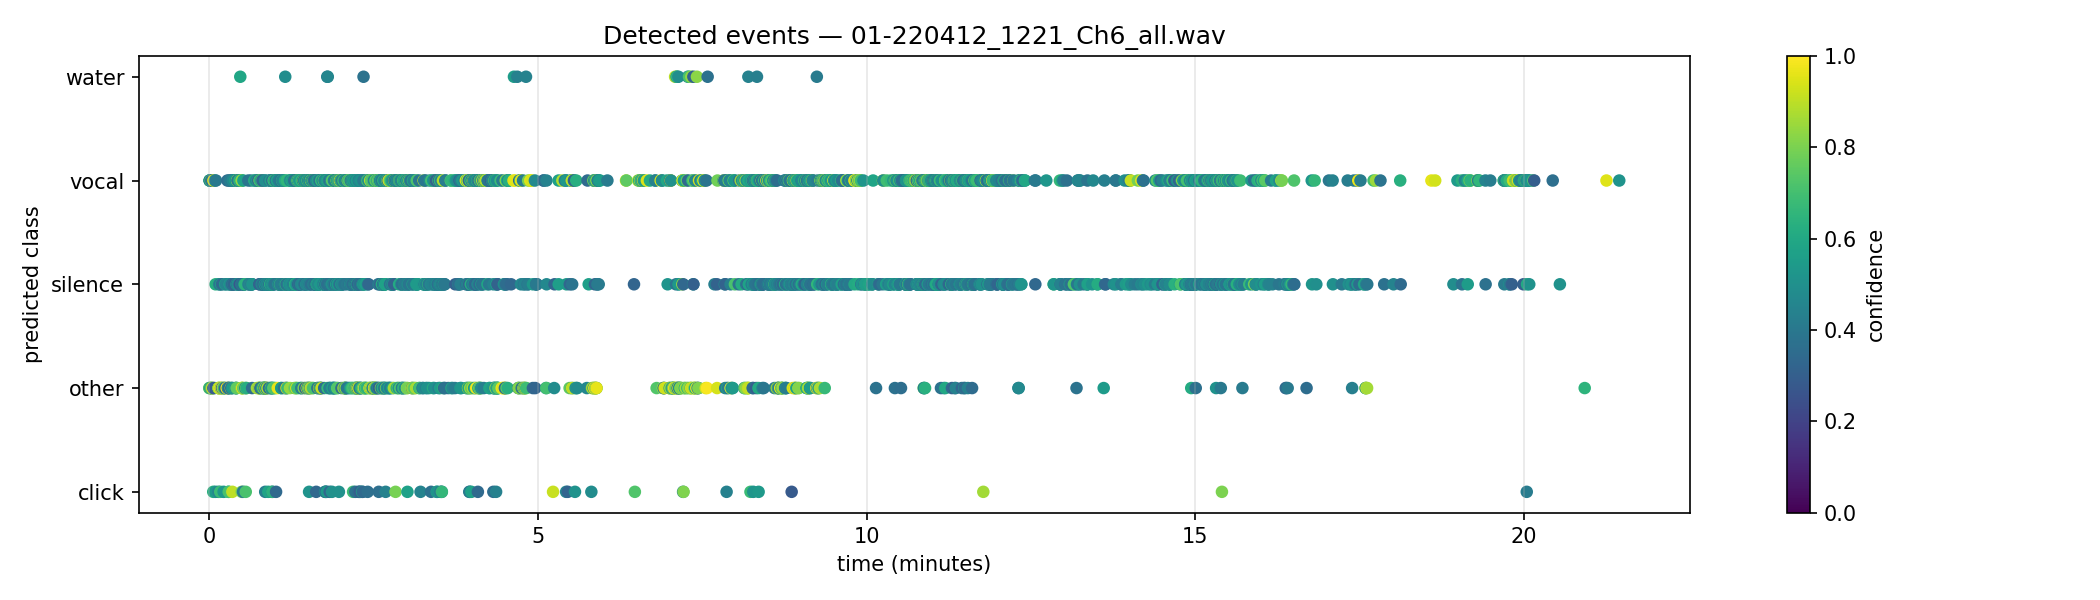

In [7]:
# Timeline of detected events over the whole recording, coloured by confidence
plot_timeline(rows, labels, WAV.name, out_dir / 'timeline.png')
Image(str(out_dir / 'timeline.png'))

## 6. Stage 4 — Evaluate against the selection table

The Raven selection table gives exact `(start, end, label)` for every annotation. We score with
**greedy 1-to-1 matching** (`evaluate_detection.score`): each true event may claim **at most one**
detection, and each detection at most one true event.

> **Why 1-to-1 matters.** An earlier version counted a true event as "found" if *any* detection
> fell within ±1 s. But this detector fires **~35× more often than there are annotations**, so
> every true event has several stray detections sitting near it — recall came out ~100% purely
> from *density*, not skill. Even random timestamps would have scored ~100% that way. With 1-to-1
> matching a true event can only be credited to one detection, so the headline becomes honest and
> **every unclaimed detection is a counted false positive.**

We report, per class:
- **detect-recall** — of the true events, how many did the detector *find* (regardless of label)?
- **correctly_classified** — of the true events, how many got the **right label**. *This is the
  per-class accuracy* (e.g. vocal `43/46 (93%)` = 43 of 46 real vocals correctly called vocal).
- **precision** — of all detections we *predicted* a class, how many landed on a true event of that
  class (denominator includes the unmatched false positives → looks low because of over-detection).
- **confusion (true→pred)** — what the true events of each class actually got called.

> The tables only *partially* annotate these dense recordings, so some detections in unmarked gaps
> are real-but-unmarked sounds — **detect-recall and correctly_classified are trustworthy;
> precision is a pessimistic lower bound.**

In [8]:
from src.inference.evaluate_detection import (
    load_selection_table, load_detections, score, find_selection_table)
from src.data.config import CLASSES
import pandas as pd

tbl = find_selection_table(WAV)
gt = load_selection_table(tbl)                  # [(start_s, end_s, label), ...]
dets = load_detections(WAV)                     # reads the events.csv we just wrote
TOL = 0.5

# Greedy 1-to-1 matching (see evaluate_detection.score): each true event may claim
# at most ONE detection. This is what keeps recall honest — with "any detection
# within ±tol counts", a detector firing 35x too often scores ~100% recall purely
# from density. Here every unclaimed detection is a counted false positive.
res = score(gt, dets, TOL)
n_true, n_det = len(gt), len(dets)
n_matched, n_correct, n_fp = res['n_matched'], res['n_correct'], n_det - res['n_matched']

print(f'ground-truth events : {n_true}')
print(f'detected events     : {n_det}   ({n_det/n_true:.1f} detections per true event)')
print(f'located a true event: {n_matched}   (recall {100*n_matched/n_true:.1f}%)')
print(f'  ...correct label  : {n_correct}   ({100*n_correct/n_true:.1f}% of true events)')
print(f'false positives     : {n_fp}   ({100*n_fp/n_det:.1f}% of detections land on no annotation)')
print('NOTE: tables are partially annotated → precision is a pessimistic lower bound.')

table = []
for c in CLASSES:
    if not res['total'][c] and not res['prec_total'][c]:
        continue
    preds = {p: n for (l, p), n in res['confusion'].items() if l == c}
    true_c = res['total'][c]
    correct_c = preds.get(c, 0)                  # true events of class c that were labelled c
    table.append({
        'class': c,
        'true': true_c,
        'detect_recall': f"{res['found'][c]}/{true_c}" if true_c else '—',
        # per-class ACCURACY — of the true events of this class, how many got the right label
        'correctly_classified': f"{correct_c}/{true_c} ({100*correct_c/true_c:.0f}%)" if true_c else '—',
        'precision': f"{res['prec_hit'][c]}/{res['prec_total'][c]}" if res['prec_total'][c] else '—',
        'confusion (true→pred)': ', '.join(
            f'{p}:{n}' for p, n in sorted(preds.items(), key=lambda x: -x[1])),
    })
pd.DataFrame(table).set_index('class')

ground-truth events : 83
detected events     : 2888   (34.8 detections per true event)
located a true event: 82   (recall 98.8%)
  ...correct label  : 57   (68.7% of true events)
false positives     : 2806   (97.2% of detections land on no annotation)
NOTE: tables are partially annotated → precision is a pessimistic lower bound.


,true,detect_recall,correctly_classified,precision,confusion (true→pred)
class,,,,,
click,3,3/3,1/3 (33%),1/66,"vocal:1, other:1, click:1"
other,28,27/28,11/28 (39%),11/503,"other:11, vocal:9, silence:4, click:2, water:1..."
silence,5,5/5,2/5 (40%),2/965,"vocal:3, silence:2"
vocal,46,46/46,43/46 (93%),43/1333,"vocal:43, other:3"
water,1,1/1,0/1 (0%),0/21,silence:1


## 7. Summary

This notebook demonstrated the supported long-file pipeline end-to-end on a single recording:
**detect → embed (single-pass) → classify → evaluate**, with honest greedy 1-to-1 scoring.

On the held-out `01-220412` file the **domain-adapted** head found 82/83 events (99% recall) and
correctly classified ~69% of them (vocals **43/46**) — versus ~29% for the clean-clip baseline.

> **The full cross-file evaluation and findings** — single-pass baseline, the class-separability
> analysis, domain adaptation (val 48→66%, vocals →88%), and the `background` class that cuts
> over-detection (52.8×→2.9×) — live in the written report:
> **[`results/detection/REPORT.md`](../results/detection/REPORT.md)**.

Use `main.ipynb` to train the clean-clip classifier on annotated clips; detector settings are in
`src/data/config.py` (`DETECT_*`). The command-line scripts behind each stage are listed in the
report's *Reproducibility* section.